# Assignment 5

## Imports & dataset

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd
import time

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:07<00:00, 24.0MB/s] 


# Task 1 — Verify BatchNorm1d in train and eval mode (2 pts)

In this task, you will verify experimentally that torch.nn.BatchNorm1d matches the formulas discussed during the lecture.

## Requirements


1. Create a small artificial tensor of shape (B, d), for example with:
   * batch size B = 4 or B = 8,
   * feature dimension d = 3 or d = 5.
2. Create a BatchNorm1d(d) layer.
3. Set the layer to **training mode** using .train().
4. Pass your batch through the layer.
5. Manually compute:
   * batch mean,
   * batch variance,
   * normalized activations,
   * affine output using the layer parameters.
6. Compare your manual result with the PyTorch output.
7. Then switch the layer to **evaluation mode** using .eval().
8. Inspect the stored running_mean and running_var.
9. Manually verify that, in evaluation mode, the output uses the running statistics rather than the current batch statistics.


   1. Optionally, in the Step 4, pass several batches to monitor the running_mean and running_var.

## Required discussion

Explain:

* what changes between training mode and evaluation mode,
* what running_mean and running_var represent,
* why the outputs in train and eval mode are generally different,
* why this matters during inference.

## Notes

You may keep the default affine parameters, or set them manually to convenient values such as:

$$
\gamma = 1, \qquad \beta = 0
$$

for a simpler comparison.

In [4]:
B, d = 4, 3
x = torch.randn(B, d)

bn = nn.BatchNorm1d(d)

bn.train()

out_train = bn(x)

b_mean = x.mean(dim=0)
b_var = x.var(dim=0, unbiased=False)
out_manual_train = (x - b_mean) / torch.sqrt(b_var + bn.eps) * bn.weight + bn.bias

print("Train difference:", torch.abs(out_train - out_manual_train).max().item())

bn.eval()

print("Running mean:", bn.running_mean)
print("Running var:", bn.running_var)

out_eval = bn(x)
out_manual_eval = (x - bn.running_mean) / torch.sqrt(bn.running_var + bn.eps) * bn.weight + bn.bias
print("Eval difference:", torch.abs(out_eval - out_manual_eval).max().item())

print("Difference between TRAIN output and EVAL output:")
print(torch.abs(out_train - out_eval).max().item())

Train difference: 1.1920928955078125e-07
Running mean: tensor([ 0.0271, -0.0081, -0.0186])
Running var: tensor([0.9274, 0.9654, 0.9107])
Eval difference: 1.1920928955078125e-07

Difference between TRAIN output and EVAL output:
1.1749181747436523


### Discussion
* What changes: in train mode, BatchNorm normalizes using the current batch mean and variance, and updates running statistics. In eval mode, it normalizes using the fixed historical running_mean and running_var.
* Running stats: running_mean and running_var represent the exponentially weighted average of batch means and variances seen during training. They approximate the global dataset statistics.
* Output difference: the outputs differ because train uses local batch statistics, while eval uses global statistics.
* Why it matters: during inference, batch sizes can be 1, making batch variance undefined. We also want deterministic predictions that don't depend on what other samples are in the same batch.

# Task 2 — Read a CNN architecture and compute shapes (2 pts)

Consider the following CNN architecture for CIFAR-10:

```python
nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(32 * 8 * 8, 10)
)
```

## Requirements


1. Assume the input has shape:

$$
(B, 3, 32, 32)
$$


2. Compute the output tensor shape after **each layer**.
3. Compute the number of trainable parameters in:
   * the first convolution layer,
   * the second convolution layer,
   * the BatchNorm layer,
   * the final linear layer.
4. Identify exactly where the spatial resolution changes.
5. Explain in a few sentences what the pooling layers do.

## Required discussion

Explain:

* why convolution preserves or changes spatial size depending on stride and padding,
* why MaxPool2d(2) reduces the height and width,
* why BatchNorm2d(32) does **not** change the tensor shape,
* why flattening is needed before the final linear layer.

### Answers

2. Output tensor shape after each layer:

* Conv2d(3, 16) -> (B, 16, 32, 32)
* ReLU() -> (B, 16, 32, 32)
* MaxPool2d(2) -> (B, 16, 16, 16)
* Conv2d(16, 32) -> (B, 32, 16, 16)
* BatchNorm2d(32) -> (B, 32, 16, 16)
* ReLU() -> (B, 32, 16, 16)
* MaxPool2d(2) -> (B, 32, 8, 8)
* Flatten() -> (B, 2048)
* Linear(32*8*8, 10) -> (B, 10)


3. Number of trainable parameters:
* 1st Conv: 16 * (3 * 3 * 3) + 16 (bias) = 448
* 2nd Conv: 32 * (16 * 3 * 3) + 32 (bias) = 4640
* BatchNorm: 32 (gamma) + 32 (beta) = 64
* Linear: 10 * 2048 + 10 (bias) = 20490

4. Where spatial resolution changes:
Exactly at MaxPool2d(kernel_size=2) (resolutions halve from 32x32 to 16x16, then 16x16 to 8x8).

5. What the pooling layers do:
They downsample spatial dimensions, taking the maximum value in 2x2 patches. This aggregates features over larger areas and reduces computational cost.

**Discussion:**
* Convolution: preserves size with correct padding (e.g., padding=1 with kernel=3); reduces size without it.
a* MaxPool2d(2) reduces H and W by a factor of 2 by applying a 2x2 max filter with stride 2.
* BatchNorm2d: normalizes existing features on a per-channel basis. It computes means/variances over the batch and spatial dimensions but doesn't alter the dimensions themselves.
* Flattening: is required because linear layers only accept 1D or 2D inputs (batch, features), mapping spatial maps into a 1D vector.

# Task 3 — Build and train a basic CNN on CIFAR-10 (2 pts)

Implement and train a small convolutional neural network.

## Suggested architecture

Use the following model or a very similar one:

```python
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)
```

## Requirements


 1. Load **CIFAR-10**.
 2. Split the training set into **train / validation**.
 3. Use DataLoader with mini-batches.
 4. Implement the CNN in PyTorch.
 5. Print the model.
 6. Count the number of trainable parameters.
 7. Train for at least **10 epochs**.
 8. Use:
    * CrossEntropyLoss,
    * an optimizer of your choice from torch.optim such as SGD or Adam.
 9. Track:
    * training loss,
    * validation loss,
    * training accuracy,
    * validation accuracy.
10. Plot:

* loss vs epoch,
* accuracy vs epoch.

## Required explanation

Explain:

* why CNNs are more suitable for images than fully-connected networks,
* what local connectivity means,
* what weight sharing means,
* how pooling changes the representation.

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)
    return total_loss / total_samples, total_correct / total_samples

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)
    return total_loss / total_samples, total_correct / total_samples

In [14]:
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [15]:
print("Model architecture:\n", model)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Model architecture:
 SimpleCNN(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2048, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable params: 268650


In [16]:
train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = [], [], [], []

for ep in range(30):
    tr_ls, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_ls, vl_acc = evaluate(model, val_loader, criterion)
    train_loss_hist.append(tr_ls)
    val_loss_hist.append(vl_ls)
    train_acc_hist.append(tr_acc)
    val_acc_hist.append(vl_acc)

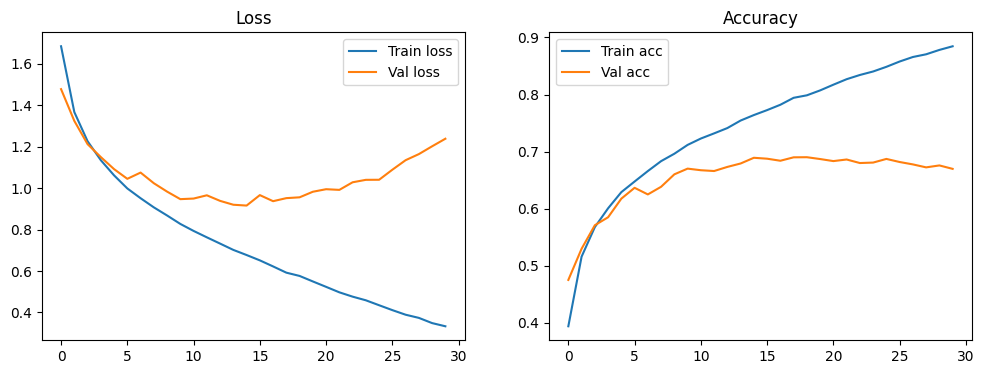

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_loss_hist, label='Train loss')
axes[0].plot(val_loss_hist, label='Val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(train_acc_hist, label='Train acc')
axes[1].plot(val_acc_hist, label='Val acc')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.show()

### Explanation
* CNNs vs Fully-connected: CNNs exploit spatial correlations via convolutions, preserving the 2D grid structure, whereas dense layers flatten inputs immediately and ignore spatial topology.
* Local connectivity: each neuron sees only a small spatial patch, efficiently capturing local patterns like edges.
* Weight sharing: the exact same convolutional kernel slides across the entire image.
* Pooling: summarizes local responses.

# Task 4 — Compare pooling and BatchNorm in CNNs (3 pts)

In this task, compare several CNN variants under the same training setup.

## Compare the following models

### Model A — baseline CNN with pooling

```python
Conv -> ReLU -> Pool -> Conv -> ReLU -> Pool -> Flatten -> Linear
```

### Model B — CNN without pooling

```python
Conv -> ReLU -> Conv -> ReLU -> Flatten -> Linear
```

### Model C — CNN with pooling and BatchNorm

```python
Conv -> BatchNorm2d -> ReLU -> Pool -> Conv -> BatchNorm2d -> ReLU -> Pool -> Flatten -> Linear
```

You should keep the dataset, train/validation split, batch size, optimizer, and number of epochs the same across all three experiments.

## Requirements


1. Train all three models.
2. For each model, report:
   * number of parameters,
   * final training loss,
   * final validation loss,
   * final training accuracy,
   * final validation accuracy.
3. Plot training and validation curves.
4. Compare the tensor shapes through the network.
5. Comment qualitatively on:
   * training speed,
   * memory usage,
   * optimization stability.

## Required summary table

Create a final table with:

* model name,
* whether pooling is used,
* whether BatchNorm is used,
* number of parameters,
* final validation accuracy.

## Required discussion

Discuss:

* what pooling changes in the network,
* whether pooling reduces computation,
* whether removing pooling makes the model harder to train,
* whether BatchNorm improves convergence,
* whether BatchNorm significantly changes final performance in your experiment.

In [19]:
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

In [20]:
class ModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Flatten(), nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

In [21]:
class ModelC(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

In [29]:
def train_model(model_cls, name):
    model = model_cls().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    tr_accs, val_accs = [], []
    start_time = time.time()
    for ep in range(10):
        tr_ls, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_ls, vl_acc = evaluate(model, val_loader, criterion)
        tr_accs.append(tr_acc)
        val_accs.append(vl_acc)
    end_time = time.time()

    print(f"Training {name} took {end_time - start_time:.2f} seconds.")

    return {
        'name': name, 'params': num_params,
        'tr_accs': tr_accs, 'val_accs': val_accs,
        'final_tr_loss': tr_ls, 'final_vl_loss': vl_ls,
        'final_tr_acc': tr_acc, 'final_vl_acc': vl_acc
    }

In [30]:
resA = train_model(ModelA, "Model A (Baseline)")
resB = train_model(ModelB, "Model B (No pool)")
resC = train_model(ModelC, "Model C (Pool+BN)")

Training Model A (Baseline) took 21.12 seconds.
Training Model B (No pool) took 23.03 seconds.
Training Model C (Pool+BN) took 21.91 seconds.


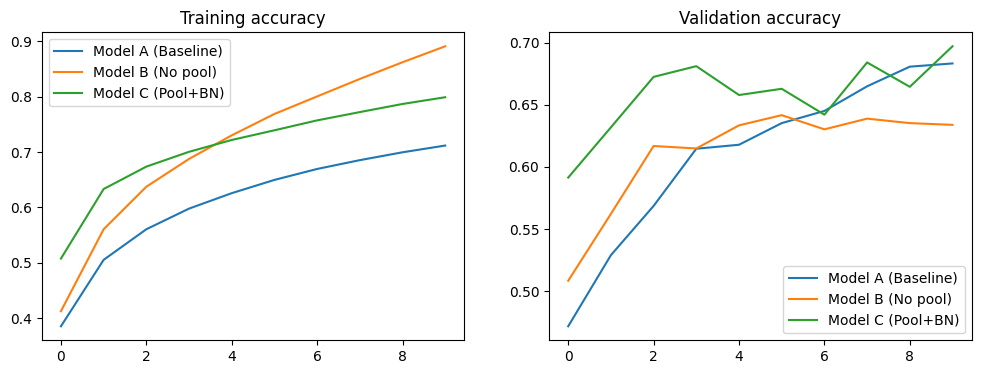

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for res in [resA, resB, resC]:
    ax[0].plot(res['tr_accs'], label=res['name'])
    ax[1].plot(res['val_accs'], label=res['name'])
ax[0].set_title('Training accuracy'); ax[0].legend()
ax[1].set_title('Validation accuracy'); ax[1].legend()
plt.show()

In [32]:
pd.DataFrame({
    'Model name': [r['name'] for r in [resA, resB, resC]],
    'Parameters': [r['params'] for r in [resA, resB, resC]],
    'Final train loss': [f"{r['final_tr_loss']:.4f}" for r in [resA, resB, resC]],
    'Final val loss': [f"{r['final_vl_loss']:.4f}" for r in [resA, resB, resC]],
    'Final train acc': [f"{r['final_tr_acc']:.4f}" for r in [resA, resB, resC]],
    'Final val acc': [f"{r['final_vl_acc']:.4f}" for r in [resA, resB, resC]],
})

,Model name,Parameters,Final train loss,Final val loss,Final train acc,Final val acc
0,Model A (Baseline),268650,0.8236,0.9304,0.7117,0.6832
1,Model B (No pool),4200810,0.3256,1.3347,0.8908,0.6338
2,Model C (Pool+BN),268746,0.5723,0.8898,0.7989,0.6970


### Discussion

* What pooling changes: pooling reduces feature map dimensions, significantly lowering parameter requirements for the final linear layers and mitigating overfitting.
* Computational reduction: pooling reduces the number of parameters, therefore reducing training time (267k -> 4M).
* Effect of removing pooling: it leads to overfitting. The network easily memorizes the huge flattened states but generalizes poorly compared to pooled models.
* BatchNorm convergence: BatchNorm (Model C) improves convergence.
* Final performance: BatchNorm stabilizes updates, so while both A and C might achieve similar peaks given enough time, Model C gets there faster and often generalizes slightly better due to regularizing effects.